In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
bgg_games = pd.read_csv('data/source/bgg_games.csv')

In [ ]:
# Moda para cada columna (guardada como lista por si hay más de una moda)
moda_por_columna = bgg_games.apply(lambda col: col.mode(dropna=True).tolist())

# Media para cada columna numérica
media_numericas = bgg_games.select_dtypes(include=[np.number]).mean()

print("Moda por columna:")
print(moda_por_columna)

print("\nMedia de columnas numéricas:")
print(media_numericas)

In [ ]:
variables_graficas =['rank_boardgame', 'average_rating', 'release_year', 'playingtime', 'weight', 'min_players', 'max_players']
df = bgg_games[variables_graficas].copy()
df.head()

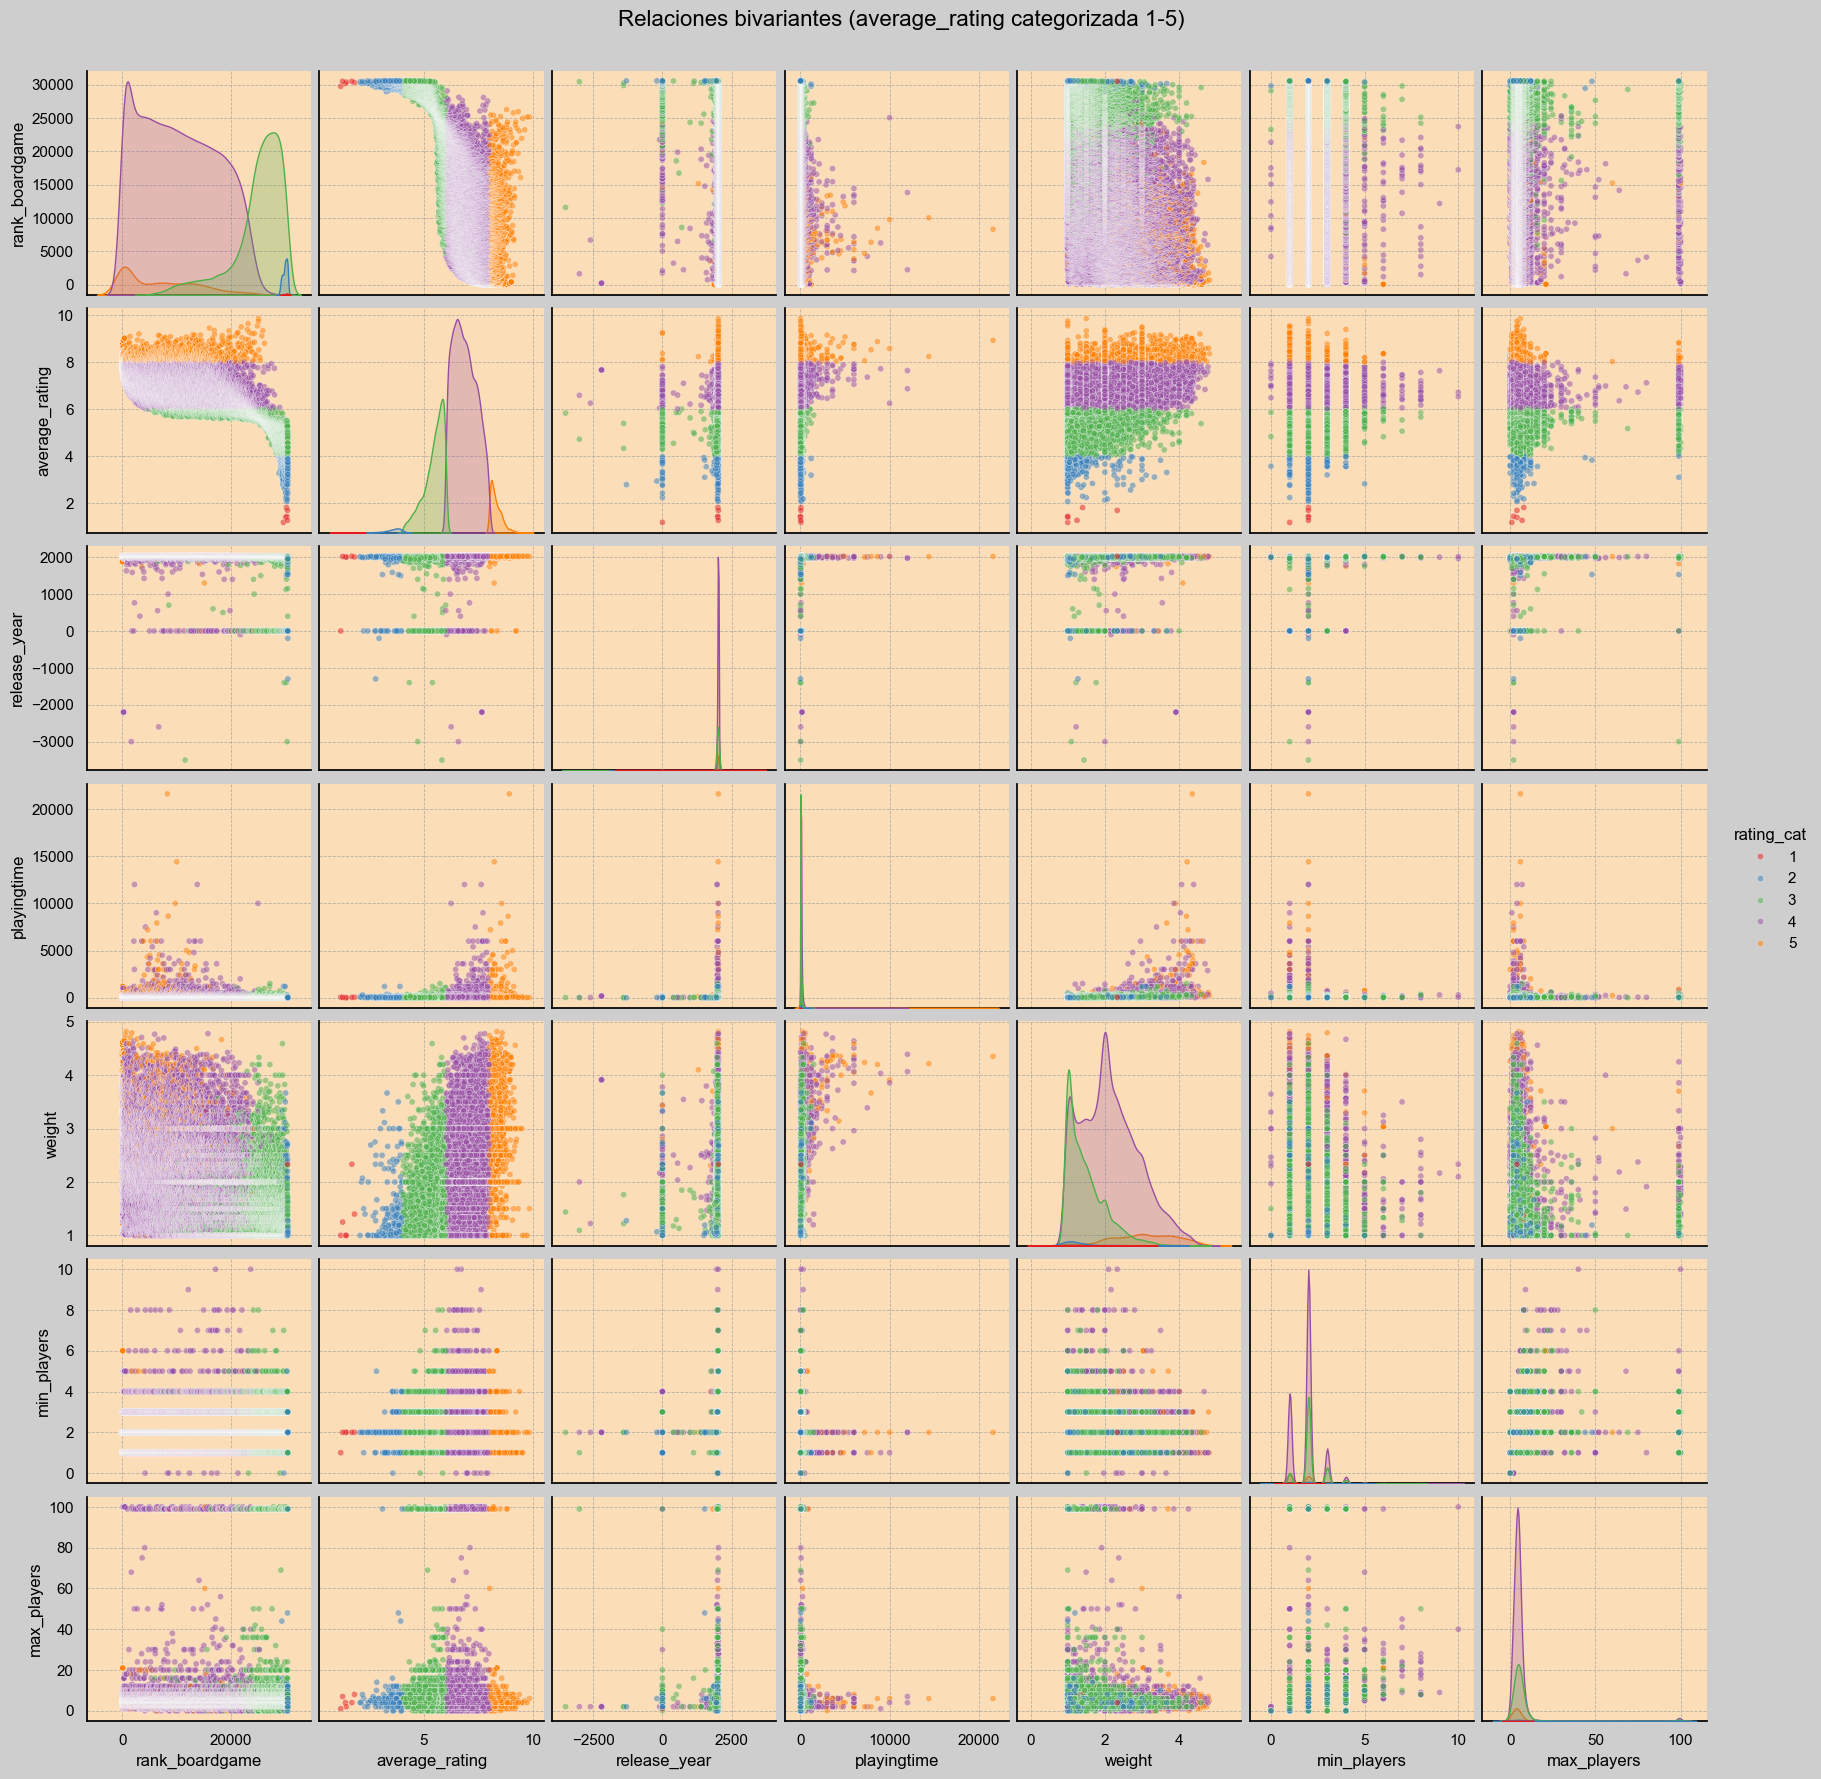

In [44]:
# Convertimos average_rating a categoría 1-5
df_plot = df.dropna().copy()

df_plot['rating_cat'] = pd.cut(
    df_plot['average_rating'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype('category')

vars_estudio = [c for c in df_plot.columns if c not in ['rating_cat']]
paleta = sns.color_palette("Set1", 5)

# Estilo general
fondo_global = "#CECECE"
fondo_grafico = "#FBDDB8"
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": fondo_global,
    "axes.facecolor": fondo_grafico,
    "axes.edgecolor": "black",
    "grid.color": "#B8B0A3",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

g = sns.pairplot(
    df_plot,
    vars=vars_estudio,
    hue='rating_cat',
    hue_order=[1, 2, 3, 4, 5],
    palette=paleta,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20}
)

g.figure.patch.set_facecolor(fondo_global)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(fondo_grafico)
        ax.grid(True, which='major', color='#B8B0A3', linestyle='--', linewidth=0.6)

g.figure.suptitle('Relaciones bivariantes (average_rating categorizada 1-5)', y=1.02, color="black", fontsize=16)
plt.show()

In [ ]:
# Convertimos average_rating a categoría 1-5
df_plot = df.dropna().copy()

df_plot['rating_cat'] = pd.cut(
    df_plot['average_rating'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype('category')

vars_estudio = [c for c in df_plot.columns if c not in ['rating_cat']]
paleta = sns.color_palette("Set1", 5)

# Estilo general
fondo_global = "#CECECE"
fondo_grafico = "#FBDDB8"
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": fondo_global,
    "axes.facecolor": fondo_grafico,
    "axes.edgecolor": "black",
    "grid.color": "#B8B0A3",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

g = sns.pairplot(
    df_plot,
    vars=vars_estudio,
    hue='rating_cat',
    hue_order=[1, 2, 3, 4, 5],
    palette=paleta,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20}
)

g.figure.patch.set_facecolor(fondo_global)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(fondo_grafico)
        ax.grid(True, which='major', color='#B8B0A3', linestyle='--', linewidth=0.6)

g.figure.suptitle('Relaciones bivariantes (average_rating categorizada 1-5)', y=1.02, color="black", fontsize=16)
if g._legend is not None:
    for handle in getattr(g._legend, "legendHandles", []):
        if hasattr(handle, "set_markersize"):
            handle.set_markersize(8)
        elif hasattr(handle, "set_sizes"):
            handle.set_sizes([80])

plt.show()

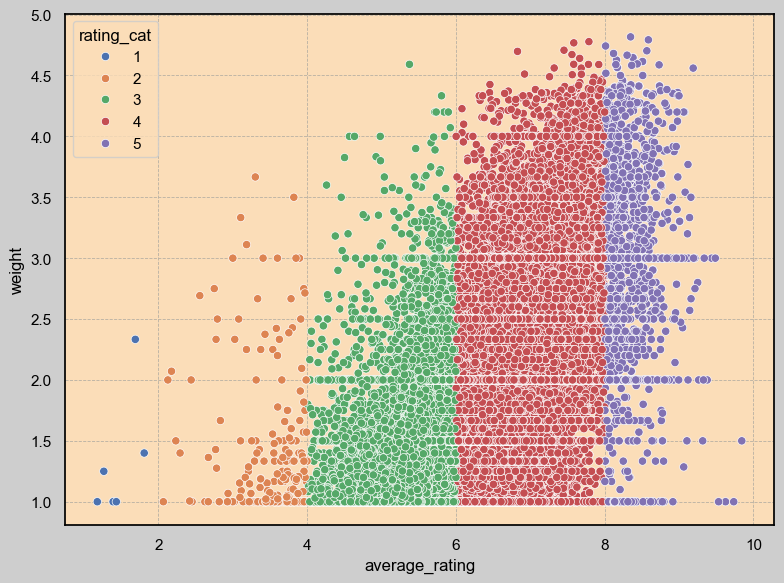

In [47]:
ax = g.axes[1, 4]
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='average_rating',
    y='weight',
    hue='rating_cat',
    ax = ax2)
fig2.tight_layout()
plt.show()

In [ ]:
correlation_matrix = df_plot.corr()
plt.Figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white')